In [1]:
#1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score,LeaveOneOut
from sklearn.model_selection import KFold
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier 
from sklearn .ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.inspection import DecisionBoundaryDisplay

In [3]:
data = pd.read_csv('F:/Dataset/price mobile/train.csv') 
data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [4]:
df=pd.DataFrame(data)

In [5]:
df.describe(include="all")  

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [6]:
print("show nane :",df.isna().sum()) 

show nane : battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


<Axes: >

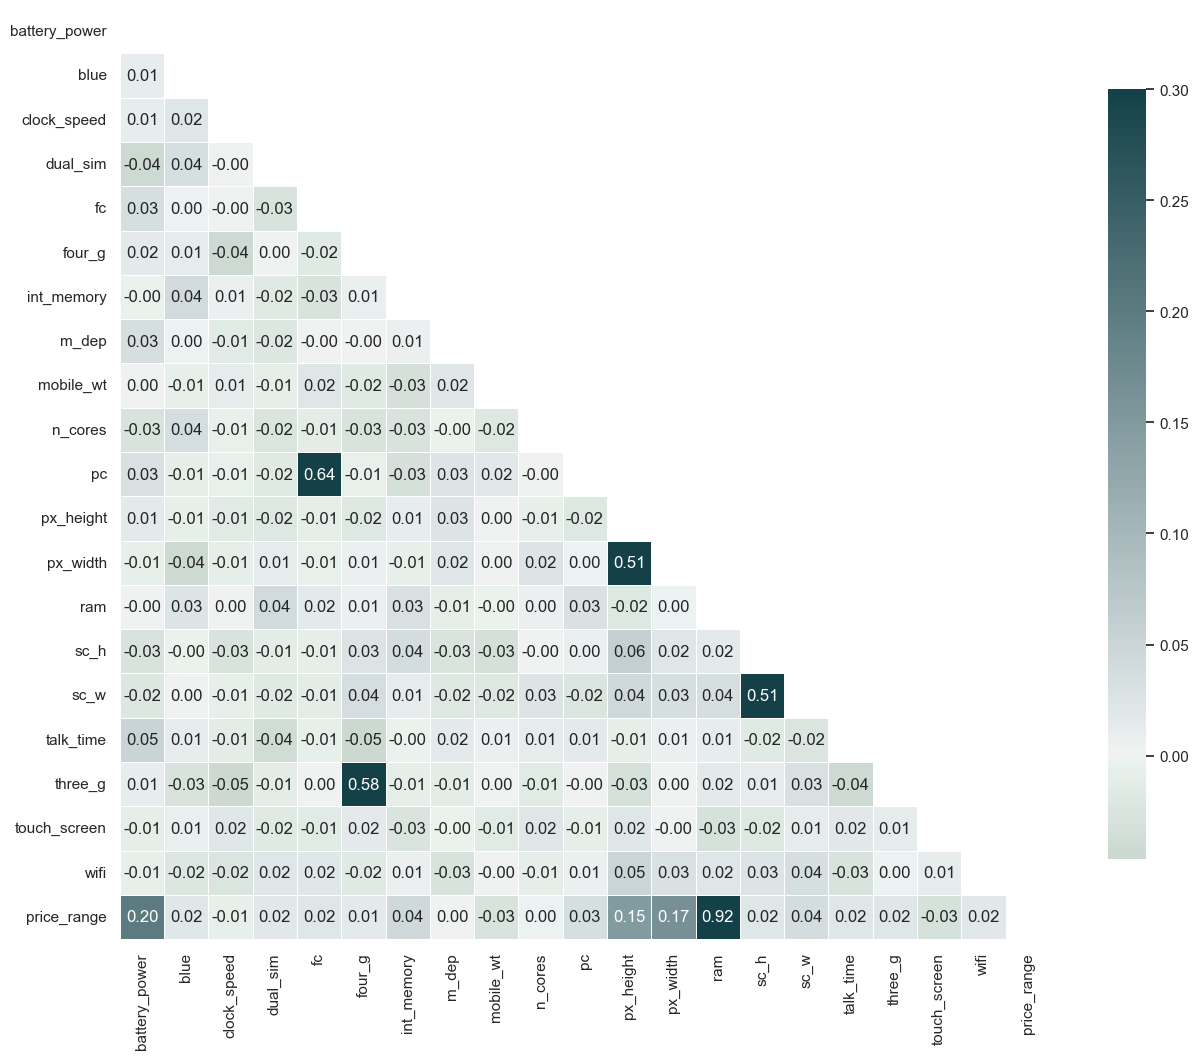

In [7]:
sns.set_theme(style="white") 
corr=df.corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
f,ax=plt.subplots(figsize=(15,20)) 
cmap=sns.diverging_palette(145,210,s=85,l=25,n=7,center="light",as_cmap=True)
sns.heatmap(corr,annot=True,fmt=".2f",mask=mask,cmap=cmap,vmax=.3,center=0,square=True,linewidths=.5,cbar_kws={"shrink":.5})

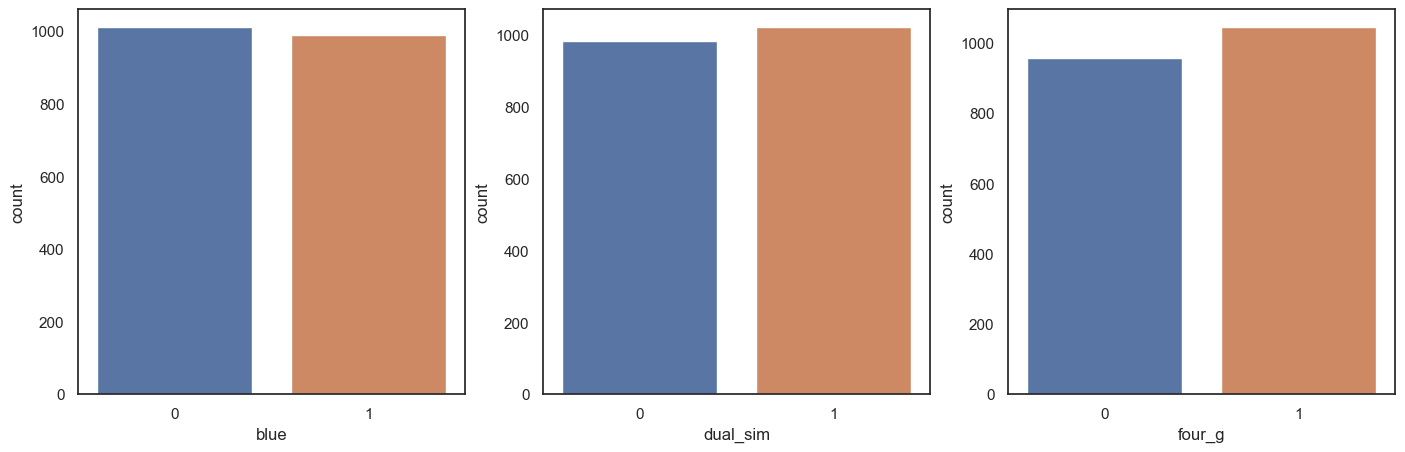

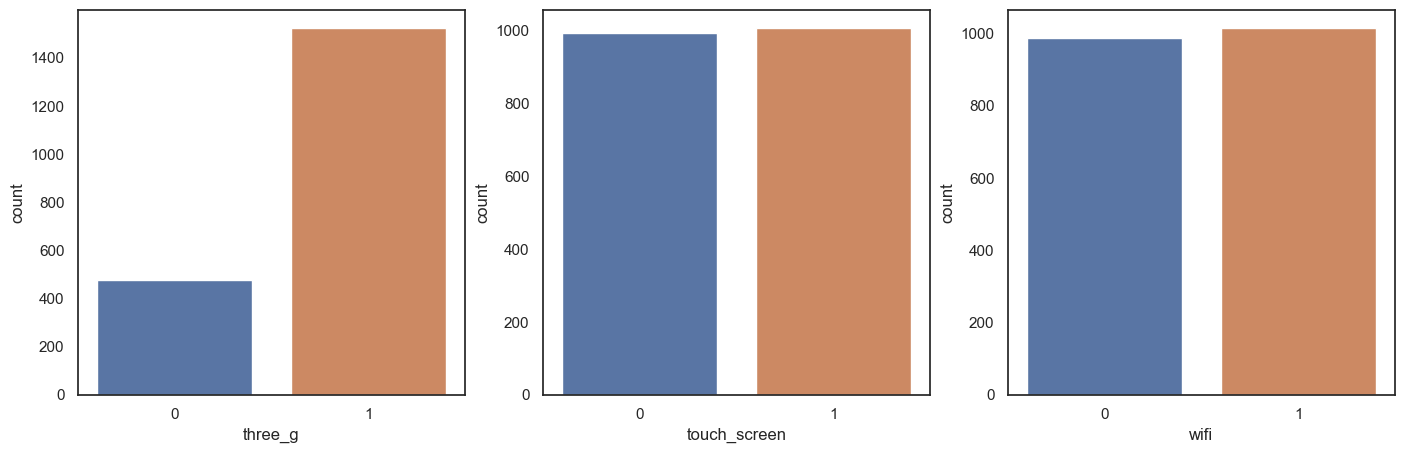

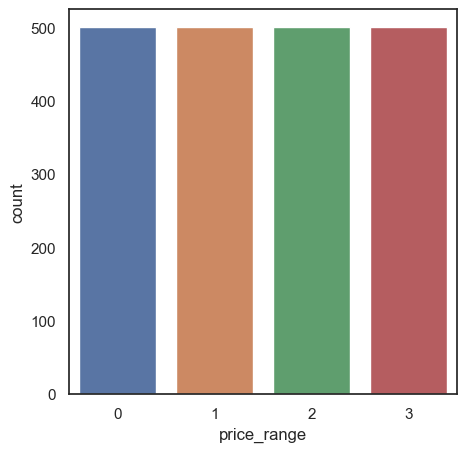

In [8]:
categorical=["blue","dual_sim","four_g","three_g","touch_screen","wifi","price_range"]
i=0
while i<8:
    plt.figure(figsize=[17,5])
    plt.subplot(1,3,1)
    sns.countplot(x=categorical[i],data=df)
    i+=1
    if i==7:
        break
    plt.subplot(1,3,2)
    sns.countplot(x=categorical[i],data=df)
    i+=1
    plt.subplot(1,3,3)
    sns.countplot(x=categorical[i],data=df)
    i+=1
    plt.show()

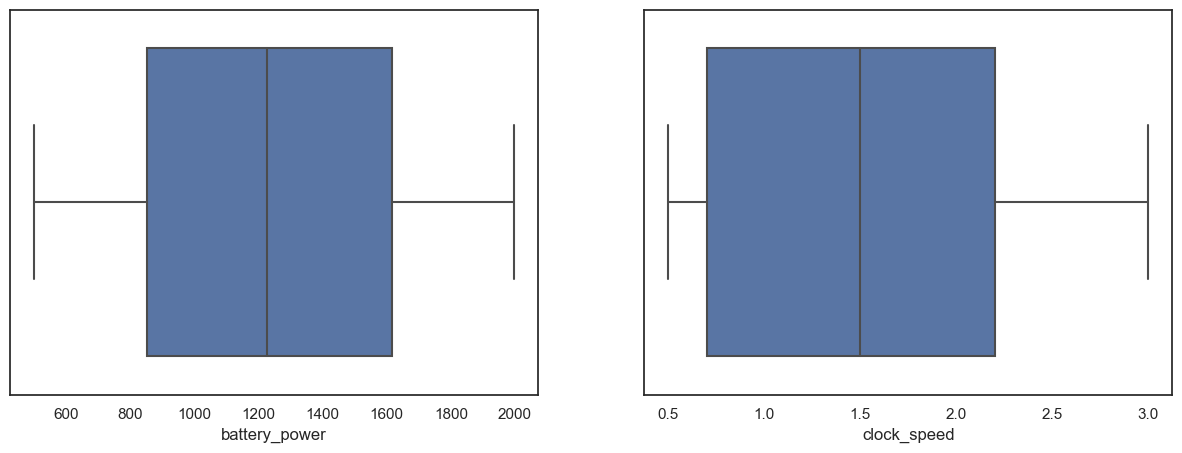

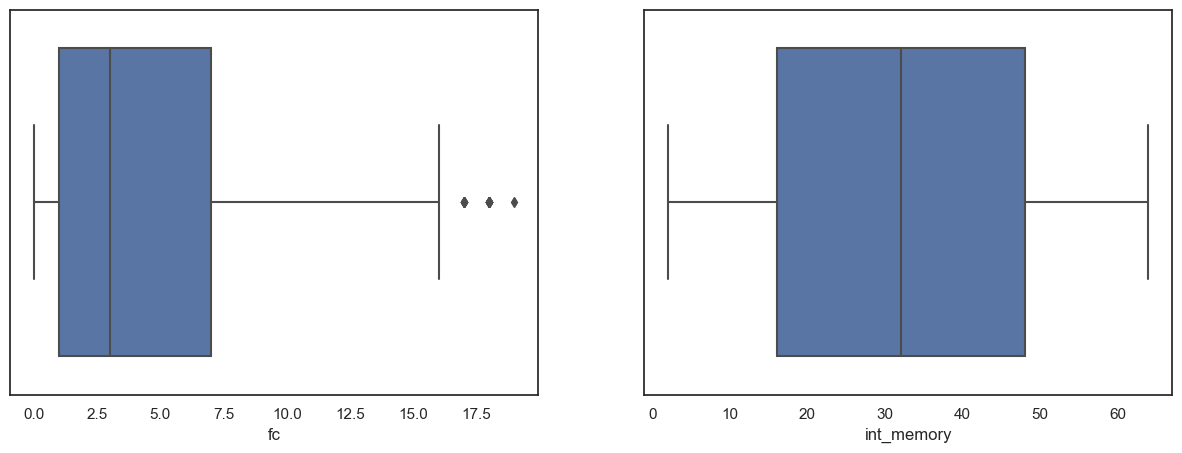

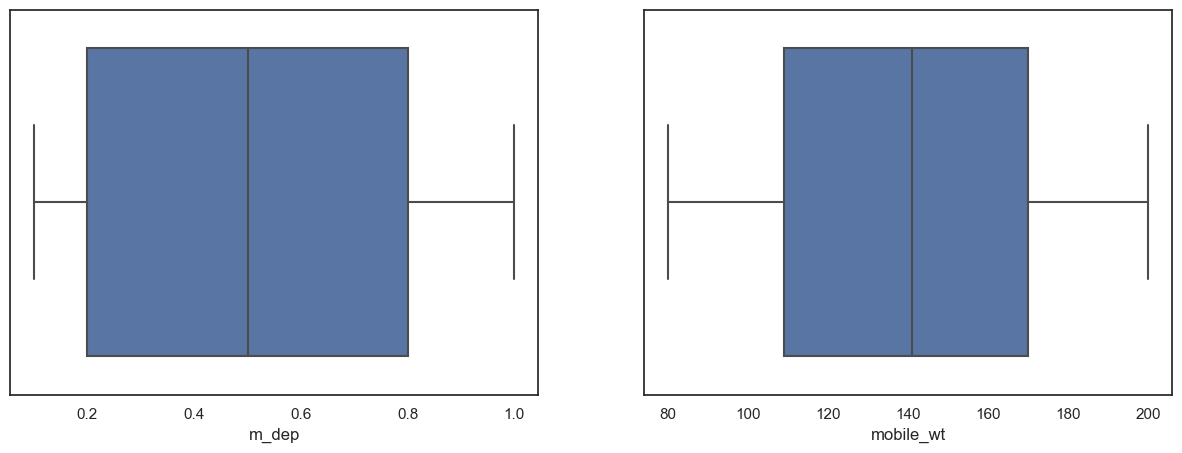

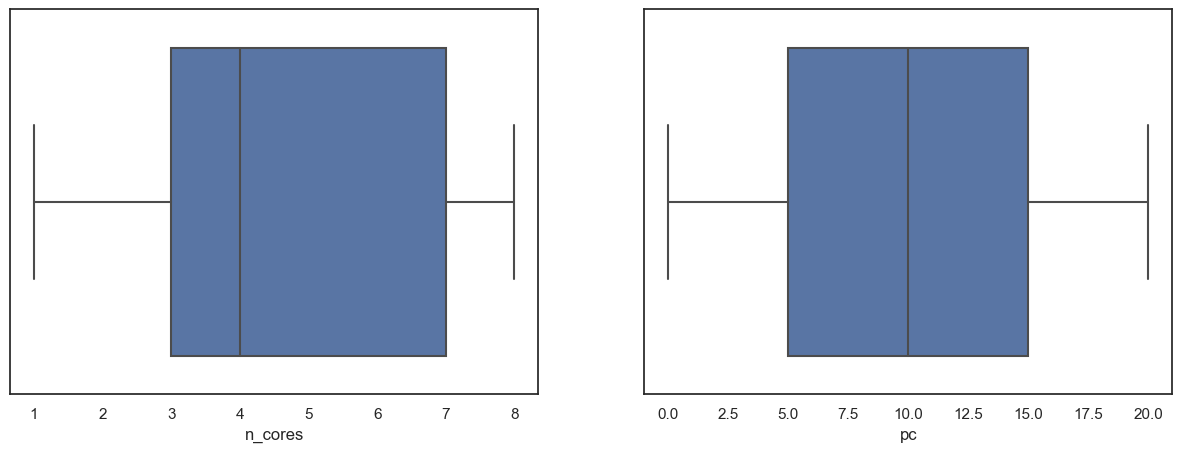

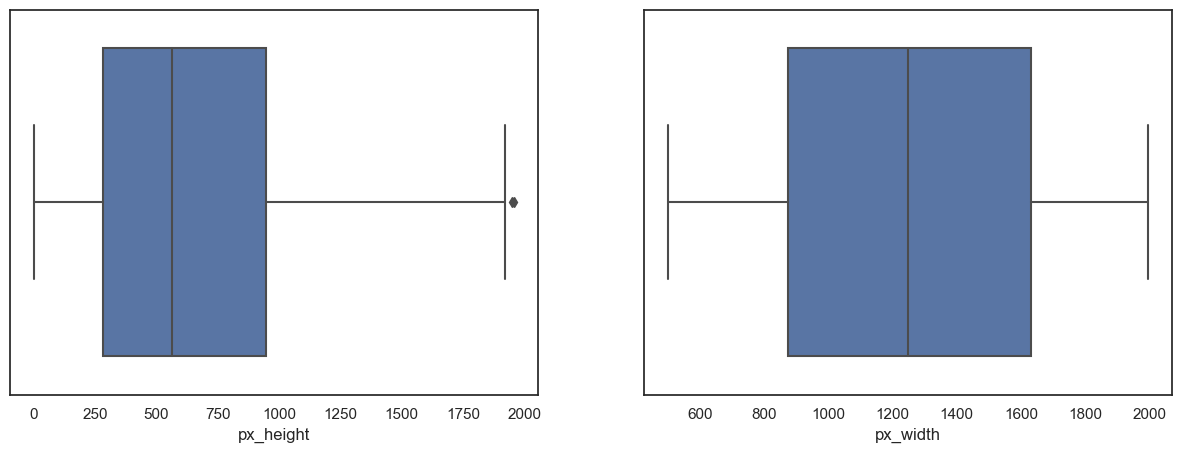

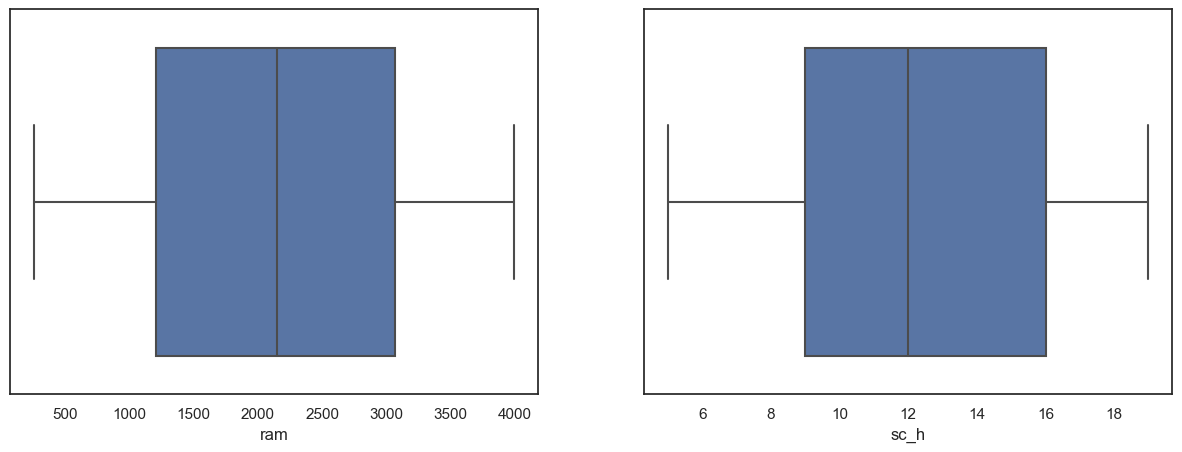

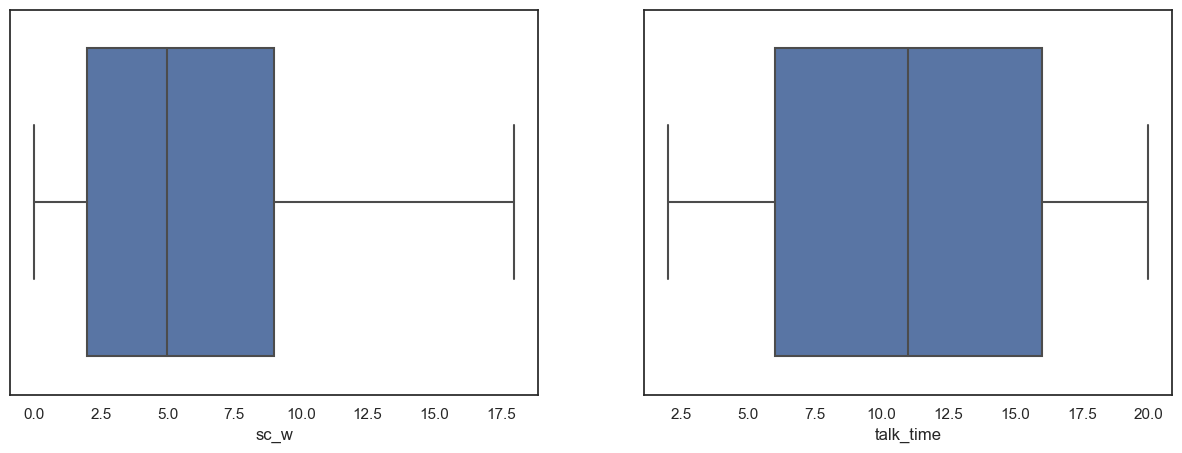

In [9]:
numerical=["battery_power","clock_speed","fc","int_memory","m_dep","mobile_wt","n_cores","pc","px_height","px_width","ram","sc_h","sc_w","talk_time"]
i=0
while i<len(numerical):
    plt.figure(figsize=[15,5])
    plt.subplot(1,2,1)
    sns.boxplot(x=numerical[i],data=df)
    i+=1
    plt.subplot(1,2,2)
    sns.boxplot(x=numerical[i],data=df)
    i+=1
    plt.show()

In [ ]:
##############چون عرض صفحه نمایش و پیکسل صفر نداریم ولی ممکنه گوشی قدیمی باشه و بقیه صفر باشند که احتمال درستی است
###########

In [10]:
df_new=df.drop(df[df["px_height"]==0].index).reset_index(drop=True)
print(len(df_new))
df_new=df.drop(df[df["sc_w"]==0].index).reset_index(drop=True)
print(len(df_new))

1998
1820


In [11]:
len(df_new[df_new["sc_w"]==0])

0

In [12]:
len(df_new[df_new["px_height"]==0])

1

In [13]:
df_new[(df_new["px_height"]==0)] 

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1756,897,1,2.0,0,3,1,2,0.6,154,8,...,0,994,1958,7,5,7,1,1,0,1


In [14]:
df_new= df_new.drop(index=[1756]).reset_index().drop(columns="index") 

In [15]:
df_new["px"]=df_new["px_height"]*df_new["px_width"]
df_new["screen"]=df_new["sc_h"]*df_new["sc_w"]*df_new["m_dep"]

In [16]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
norm = scaler.fit_transform(df_new.iloc[:,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22]])
norm_df = pd.DataFrame(norm,columns = ["battery_power","blue","clock_speed","dual_sim","fc","four_g","int_memory","m_dep","mobile_wt","n_cores",
                                    "pc","px_height","px_width","ram","sc_h","sc_w","talk_time","three_g","touch_screen","wifi","px","screen"])
norm_df["price_range"] = df_new["price_range"]

In [17]:
x=norm_df.iloc[:,:22].values
y=norm_df["price_range"].values.reshape(-1,1)
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2,random_state=0)

In [18]:
clf=DecisionTreeClassifier(criterion="log_loss",max_depth=10,random_state=247)
clf.fit(x_train,y_train.ravel())
y_pred=clf.predict(x_test)

In [19]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.8434065934065934


In [20]:
print("Accuracy :",metrics.accuracy_score(y_train,clf.predict(x_train)))

Accuracy : 0.9993127147766323


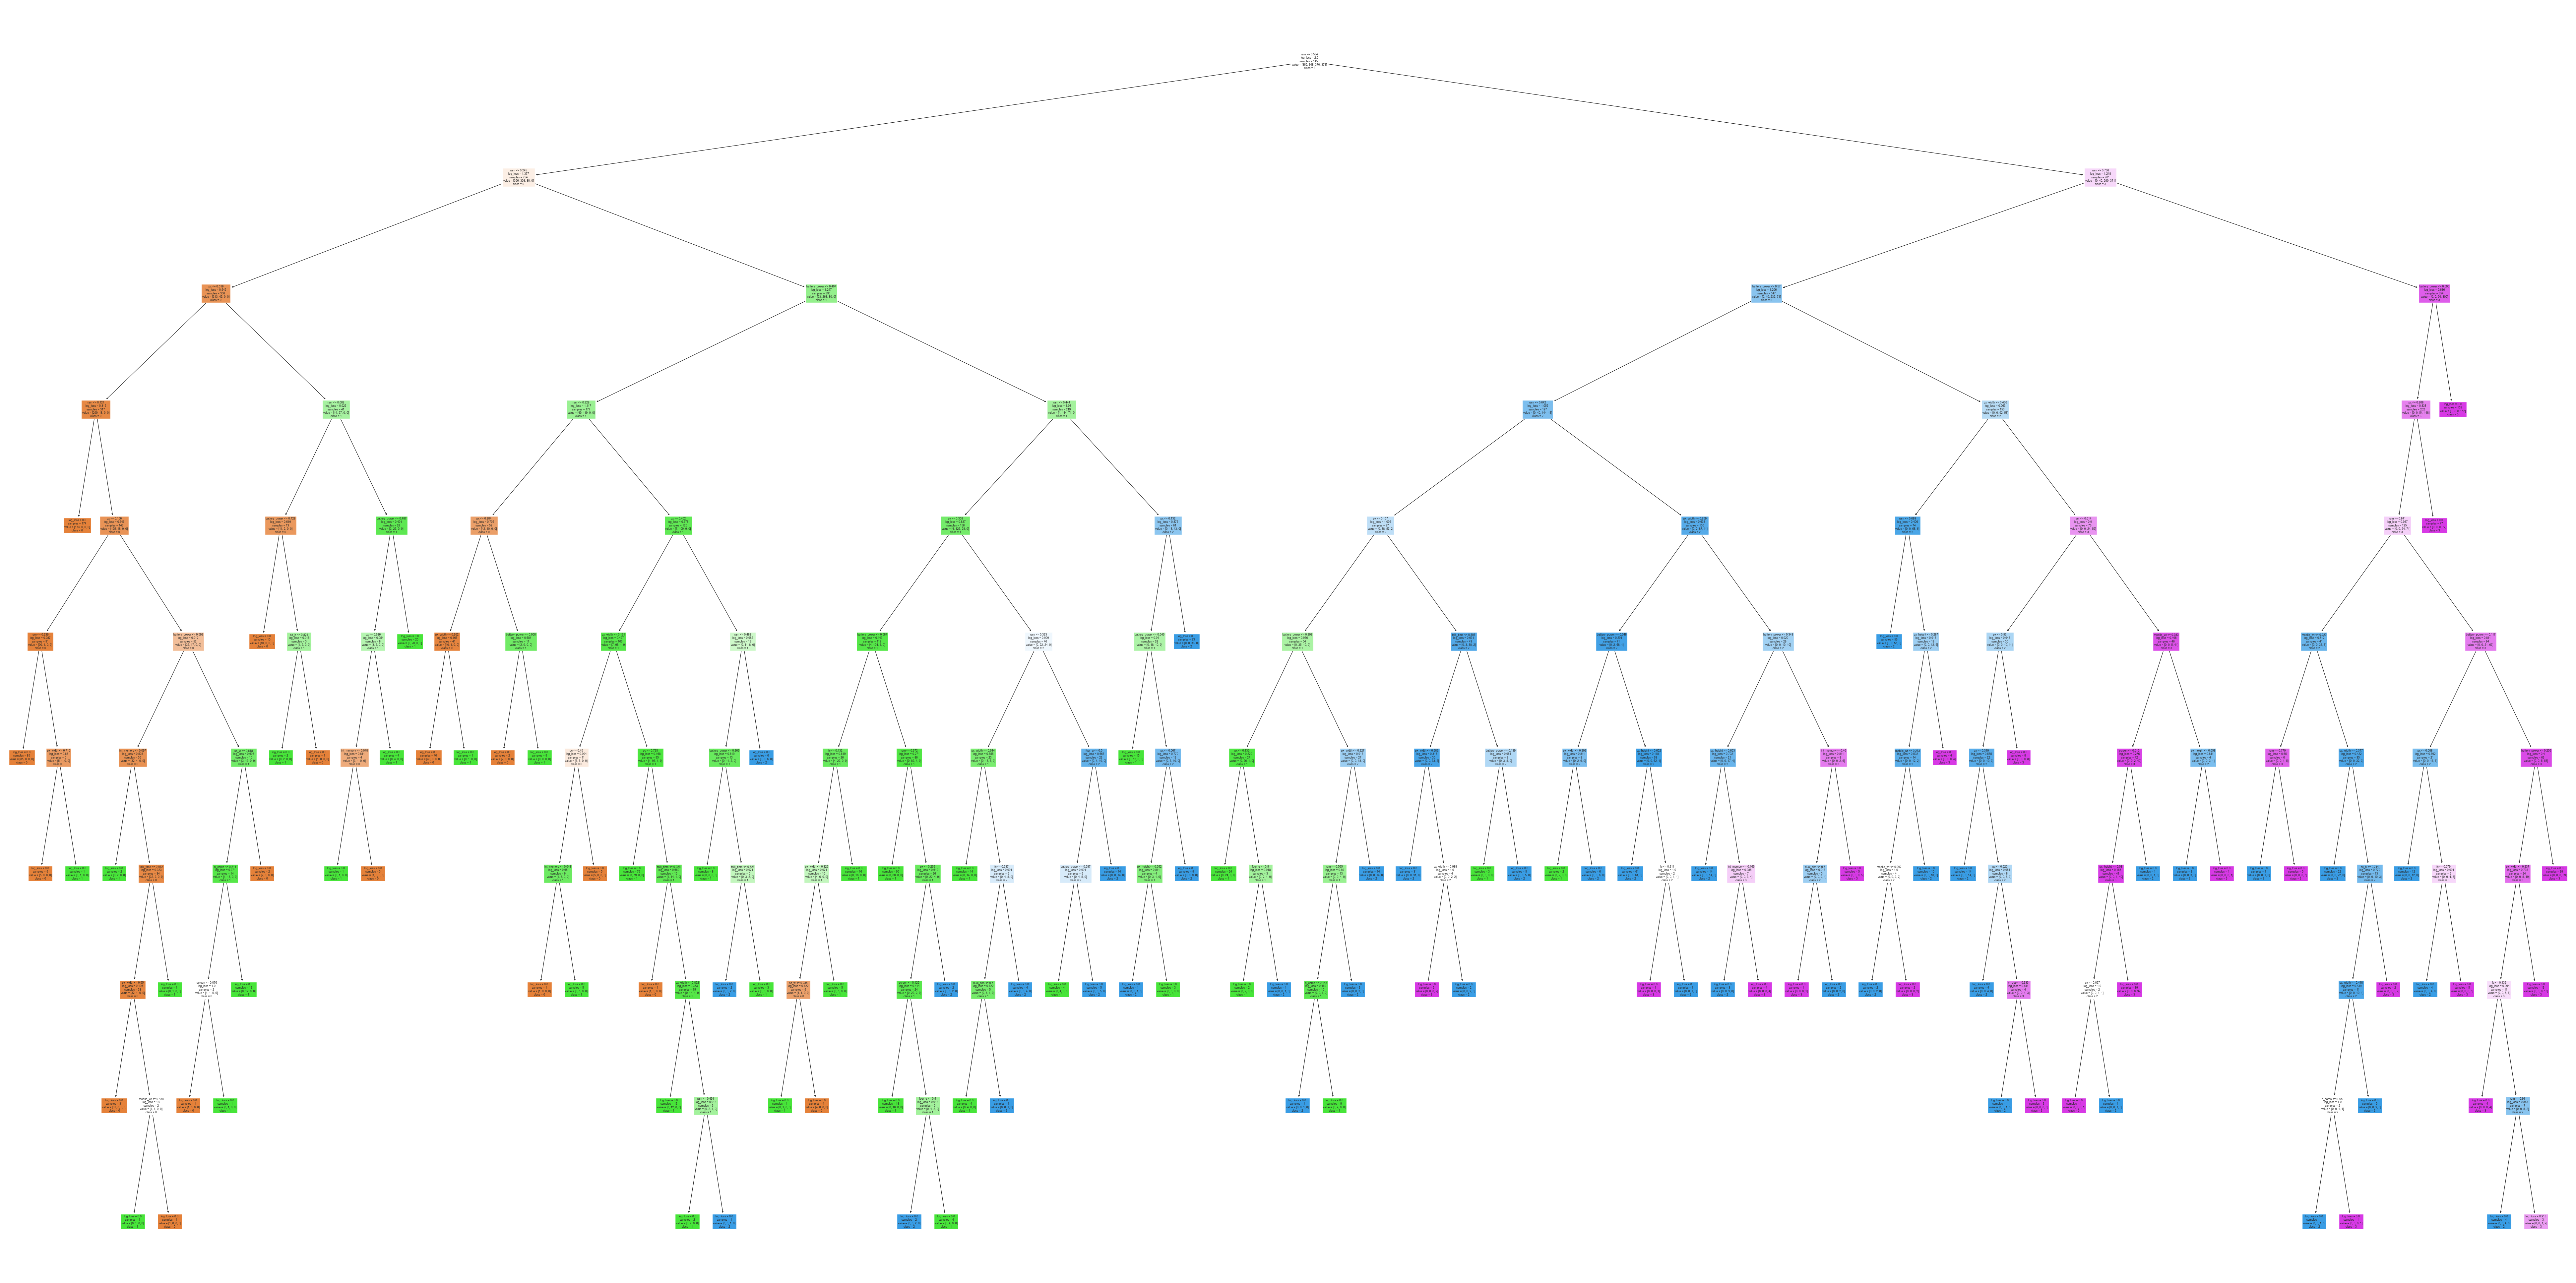

In [21]:
feature_names=["battery_power","blue","clock_speed","dual_sim","fc","four_g","int_memory","m_dep","mobile_wt","n_cores",
                "pc","px_height","px_width","ram","sc_h","sc_w","talk_time","three_g","touch_screen","wifi","px","screen"]
target_names=["0","1","2","3"]
fig=plt.figure(figsize=(100,50))
plot=tree.plot_tree(clf,
                  feature_names=feature_names,
                  class_names=target_names,
                   filled=True)


In [22]:
print(classification_report(y,clf.predict(x)))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       451
           1       0.96      0.95      0.96       451
           2       0.95      0.96      0.96       456
           3       0.98      0.98      0.98       461

    accuracy                           0.97      1819
   macro avg       0.97      0.97      0.97      1819
weighted avg       0.97      0.97      0.97      1819



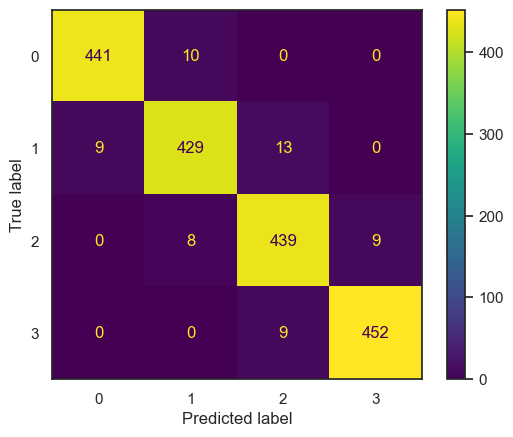

In [23]:
actual=y
predicted=clf.predict(x)

confiusion_matrix=metrics.confusion_matrix(actual,predicted)
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=confiusion_matrix)

cm_display.plot()
plt.show()

In [24]:
######random forest

In [25]:
clf1=RandomForestClassifier(n_estimators=500,criterion="gini",max_depth=10,random_state=1000,max_features=0.5)
clf1.fit(x_train,y_train.ravel())
y_pred=clf1.predict(x_test)

In [26]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.9010989010989011


In [27]:
print("Accuracy :",metrics.accuracy_score(y_train,clf.predict(x_train)))

Accuracy : 0.9993127147766323


In [28]:
print(classification_report(y,clf1.predict(x)))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       451
           1       0.98      0.97      0.98       451
           2       0.97      0.98      0.97       456
           3       0.99      0.98      0.98       461

    accuracy                           0.98      1819
   macro avg       0.98      0.98      0.98      1819
weighted avg       0.98      0.98      0.98      1819



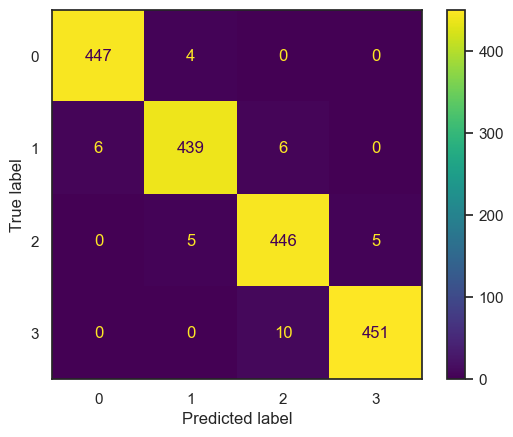

In [29]:
actual=y
predicted=clf1.predict(x)

confiusion_matrix=metrics.confusion_matrix(actual,predicted)
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=confiusion_matrix)

cm_display.plot()
plt.show()

In [30]:
##### svm

In [31]:
df_new["ram2"]=df_new["ram"]**3
df_new["battery_power2"]=df_new["battery_power"]**3

In [32]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
norm = scaler.fit_transform(df_new.iloc[:,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22,23,24]])
norm_df = pd.DataFrame(norm,columns = ["battery_power","blue","clock_speed","dual_sim","fc","four_g","int_memory","m_dep","mobile_wt","n_cores",
                                    "pc","px_height","px_width","ram","sc_h","sc_w","talk_time","three_g","touch_screen","wifi","px","screen",
                                       "ram2","battery_power2"])
norm_df["price_range"] = df_new["price_range"]

In [33]:
x=norm_df.iloc[:,:24].values
y=norm_df["price_range"].values.reshape(-1,1)
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.1,random_state=0)

In [34]:
clf2=SVC(kernel="linear",gamma="scale",random_state=99)
clf2.fit(x_train,y_train.ravel())
y_pred=clf2.predict(x_test)

In [35]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.9725274725274725


In [36]:
print("Accuracy :",metrics.accuracy_score(y_train,clf2.predict(x_train)))

Accuracy : 0.9560171044593769


In [37]:
print(classification_report(y,clf2.predict(x)))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       451
           1       0.94      0.95      0.94       451
           2       0.95      0.93      0.94       456
           3       0.97      0.97      0.97       461

    accuracy                           0.96      1819
   macro avg       0.96      0.96      0.96      1819
weighted avg       0.96      0.96      0.96      1819



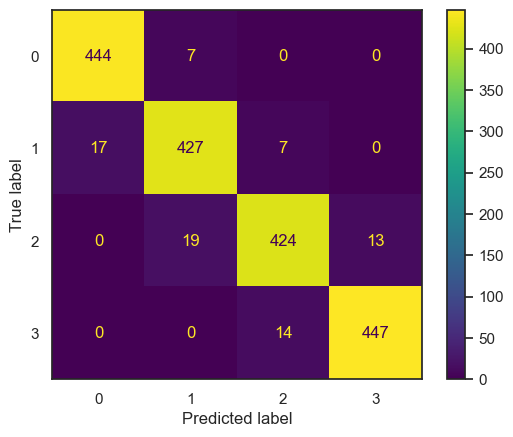

In [38]:
actual=y
predicted=clf2.predict(x)

confiusion_matrix=metrics.confusion_matrix(actual,predicted)
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=confiusion_matrix)

cm_display.plot()
plt.show()

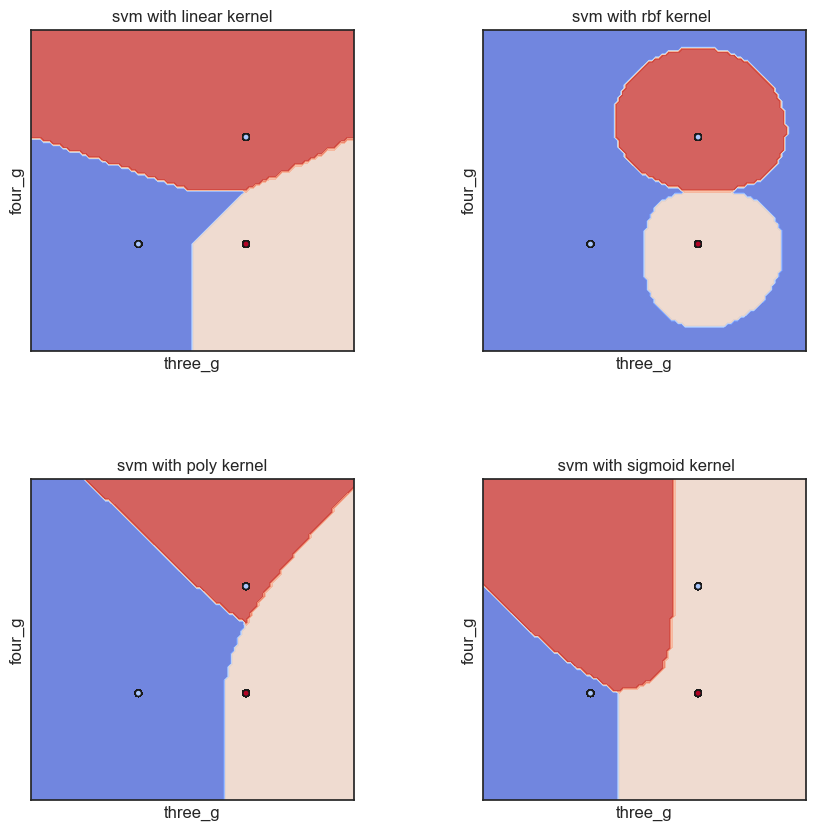

In [39]:
ts=0.1
x1=df_new[["three_g","four_g"]].values
y1=df_new["price_range"].values.reshape(-1,1)
y1=y.ravel()
x1_train, x1_test, y1_train, y1_test=train_test_split(x1,y1, test_size=ts,random_state=0)
models=(
      SVC(kernel="linear",gamma="scale"),SVC(kernel="rbf",gamma="scale"),SVC(kernel="poly",gamma="scale"),
      SVC(kernel="sigmoid",gamma="scale")
)
clfs=(clf.fit(x1_train,y1_train) for clf in models)
title=("svm with linear kernel","svm with rbf kernel ","svm with poly kernel"," svm with sigmoid kernel")    
fig,sub=plt.subplots(2,2,figsize=(10,10))
plt.subplots_adjust(wspace=0.4, hspace=0.4)
x0,x1=x1_train[:, 0],x1_train[:, 1] 

for clf, title, ax in zip(clfs,title,sub.flatten()):
    disp=DecisionBoundaryDisplay.from_estimator(
        clf,
        x1_train,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,ax=ax,xlabel="three_g",ylabel="four_g",
    )
    ax.scatter(x0, x1, c=y1_train, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
      
plt.show()      

In [40]:
########## predict

In [41]:
data_test = pd.read_csv('F:/Dataset/price mobile/test.csv') 
df_test=pd.DataFrame(data_test)
df_test

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1700,1,1.9,0,0,1,54,0.5,170,...,17,644,913,2121,14,8,15,1,1,0
996,997,609,0,1.8,1,0,0,13,0.9,186,...,2,1152,1632,1933,8,1,19,0,1,1
997,998,1185,0,1.4,0,1,1,8,0.5,80,...,12,477,825,1223,5,0,14,1,0,0
998,999,1533,1,0.5,1,0,0,50,0.4,171,...,12,38,832,2509,15,11,6,0,1,0


In [42]:
df_test.drop(columns="id",inplace=True)

In [43]:
df_test["px"]=df_test["px_height"]*df_test["px_width"]
df_test["screen"]=df_test["sc_h"]*df_test["sc_w"]*df_new["m_dep"]
df_test["ram2"]=df_test["ram"]**3
df_test["battery_power2"]=df_test["battery_power"]**3

In [44]:
df_test["price_range"]=0
df_test

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,sc_w,talk_time,three_g,touch_screen,wifi,px,screen,ram2,battery_power2,price_range
0,1043,1,1.8,1,14,0,5,0.1,193,3,...,7,2,0,1,0,319112,50.4,41999034176,1134626507,0
1,841,1,0.5,1,4,1,61,0.8,191,5,...,0,7,1,0,0,639322,0.0,59091142375,594823321,0
2,1807,1,2.8,0,1,0,27,0.9,186,3,...,10,10,0,1,1,1734820,153.0,13754995136,5900304943,0
3,1546,0,0.5,1,18,1,25,0.5,96,8,...,0,7,1,1,0,516840,0.0,59000162957,3695119336,0
4,1434,0,1.4,0,11,1,49,0.5,108,6,...,8,7,1,0,1,606690,72.0,5573476917,2948814504,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1700,1,1.9,0,0,1,54,0.5,170,7,...,8,15,1,1,0,587972,100.8,9541617561,4913000000,0
996,609,0,1.8,1,0,0,13,0.9,186,4,...,1,19,0,1,1,1880064,8.0,7222633237,225866529,0
997,1185,0,1.4,0,1,1,8,0.5,80,1,...,0,14,1,0,0,393525,0.0,1829276567,1664006625,0
998,1533,1,0.5,1,0,0,50,0.4,171,2,...,11,6,0,1,0,31616,132.0,15794358229,3602686437,0


In [45]:
df2 = df_new.append([df_test],ignore_index=True)
df2

C:\Users\Raya_Bit\AppData\Local\Temp\ipykernel_1744\3652938163.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df2 = df_new.append([df_test],ignore_index=True)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,sc_w,talk_time,three_g,touch_screen,wifi,price_range,px,screen,ram2,battery_power2
0,842,0,2.2,0,1,0,7,0.6,188,2,...,7,19,0,0,1,1,15120,37.8,16561875149,596947688
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,3,7,1,1,0,2,1799140,35.7,18212205591,1064332261
2,563,1,0.5,1,2,1,41,0.9,145,5,...,2,9,1,1,0,2,2167308,19.8,17636910227,178453547
3,615,1,2.5,0,0,0,10,0.8,131,6,...,8,11,1,0,0,2,2171776,102.4,21230922609,232608375
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,2,15,1,1,0,1,1464096,9.6,2809189531,6038510661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2814,1700,1,1.9,0,0,1,54,0.5,170,7,...,8,15,1,1,0,0,587972,100.8,9541617561,4913000000
2815,609,0,1.8,1,0,0,13,0.9,186,4,...,1,19,0,1,1,0,1880064,8.0,7222633237,225866529
2816,1185,0,1.4,0,1,1,8,0.5,80,1,...,0,14,1,0,0,0,393525,0.0,1829276567,1664006625
2817,1533,1,0.5,1,0,0,50,0.4,171,2,...,11,6,0,1,0,0,31616,132.0,15794358229,3602686437


In [46]:
print("show missing value :",df2.isnull().sum()) 

show missing value : battery_power     0
blue              0
clock_speed       0
dual_sim          0
fc                0
four_g            0
int_memory        0
m_dep             0
mobile_wt         0
n_cores           0
pc                0
px_height         0
px_width          0
ram               0
sc_h              0
sc_w              0
talk_time         0
three_g           0
touch_screen      0
wifi              0
price_range       0
px                0
screen            0
ram2              0
battery_power2    0
dtype: int64


In [47]:
df_new.shape

(1819, 25)

In [48]:
df_test.shape

(1000, 25)

In [49]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2819 entries, 0 to 2818
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   battery_power   2819 non-null   int64  
 1   blue            2819 non-null   int64  
 2   clock_speed     2819 non-null   float64
 3   dual_sim        2819 non-null   int64  
 4   fc              2819 non-null   int64  
 5   four_g          2819 non-null   int64  
 6   int_memory      2819 non-null   int64  
 7   m_dep           2819 non-null   float64
 8   mobile_wt       2819 non-null   int64  
 9   n_cores         2819 non-null   int64  
 10  pc              2819 non-null   int64  
 11  px_height       2819 non-null   int64  
 12  px_width        2819 non-null   int64  
 13  ram             2819 non-null   int64  
 14  sc_h            2819 non-null   int64  
 15  sc_w            2819 non-null   int64  
 16  talk_time       2819 non-null   int64  
 17  three_g         2819 non-null   i

In [50]:
########svm

In [51]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
norm = scaler.fit_transform(df2.iloc[:,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22,23,24]])
norm_df = pd.DataFrame(norm,columns = ["battery_power","blue","clock_speed","dual_sim","fc","four_g","int_memory","m_dep","mobile_wt","n_cores",
                                    "pc","px_height","px_width","ram","sc_h","sc_w","talk_time","three_g","touch_screen","wifi","px","screen",
                                       "ram2","battery_power2"])
norm_df["price_range"] = df2["price_range"]
norm_df.head(5)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,sc_w,talk_time,three_g,touch_screen,wifi,px,screen,ram2,battery_power2,price_range
0,0.228152,0.0,0.68,0.0,0.052632,0.0,0.080645,0.555556,0.900000,0.142857,...,0.388889,0.944444,0.0,0.0,1.0,0.003891,0.110526,0.258973,0.060021,1
1,0.347565,1.0,0.00,1.0,0.000000,1.0,0.822581,0.666667,0.466667,0.285714,...,0.166667,0.277778,1.0,1.0,0.0,0.462943,0.104386,0.284805,0.119462,2
2,0.042028,1.0,0.00,1.0,0.105263,1.0,0.629032,0.888889,0.541667,0.571429,...,0.111111,0.388889,1.0,1.0,0.0,0.557678,0.057895,0.275800,0.006798,2
3,0.076718,1.0,0.80,0.0,0.000000,0.0,0.129032,0.777778,0.425000,0.714286,...,0.444444,0.500000,1.0,0.0,0.0,0.558828,0.299415,0.332056,0.013685,2
4,0.881254,1.0,0.28,0.0,0.684211,1.0,0.677419,0.555556,0.508333,0.142857,...,0.111111,0.722222,1.0,1.0,0.0,0.376732,0.028070,0.043708,0.752067,1


In [52]:
x=norm_df.drop(["price_range"],axis=1)[:1819]
y=norm_df["price_range"][:1819].values.reshape(-1,1)
x_finall=norm_df.drop(["price_range"],axis=1)[1819:]

In [53]:
clf2=SVC(kernel="linear",gamma="scale",random_state=99)
clf2.fit(x,y.ravel())
y_pred1=clf2.predict(x_finall)

In [54]:
y_pred1

array([3, 3, 2, 3, 1, 3, 3, 1, 3, 0, 3, 3, 0, 0, 2, 0, 2, 1, 3, 2, 1, 3,
       1, 1, 3, 0, 2, 0, 3, 0, 2, 0, 3, 0, 1, 1, 3, 1, 2, 1, 1, 2, 0, 0,
       0, 1, 0, 3, 1, 2, 1, 0, 2, 0, 3, 0, 3, 1, 1, 3, 3, 3, 0, 1, 0, 1,
       2, 3, 1, 2, 1, 2, 2, 3, 3, 0, 2, 0, 2, 3, 0, 3, 3, 0, 3, 0, 3, 1,
       3, 0, 1, 1, 2, 1, 2, 1, 0, 2, 1, 2, 1, 0, 0, 3, 0, 2, 0, 1, 2, 3,
       3, 3, 1, 3, 3, 3, 3, 2, 3, 0, 0, 3, 2, 1, 2, 0, 3, 2, 2, 2, 0, 2,
       2, 1, 3, 1, 1, 0, 3, 2, 1, 2, 1, 3, 3, 3, 3, 3, 2, 3, 2, 3, 1, 0,
       3, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 1, 0, 3, 0, 0, 0, 2, 1, 0, 1,
       0, 0, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 0, 0, 0, 1, 0, 3, 1, 0, 2, 2,
       2, 3, 1, 2, 3, 2, 3, 2, 2, 1, 0, 0, 1, 2, 0, 2, 3, 3, 0, 2, 0, 3,
       2, 3, 3, 1, 0, 1, 0, 3, 0, 1, 0, 2, 2, 1, 3, 1, 3, 0, 3, 1, 2, 0,
       0, 2, 1, 3, 2, 3, 1, 1, 3, 0, 0, 2, 3, 3, 1, 3, 1, 1, 3, 2, 1, 2,
       3, 3, 3, 1, 0, 1, 2, 3, 1, 1, 3, 2, 0, 3, 0, 1, 3, 0, 0, 3, 2, 3,
       3, 2, 1, 3, 3, 2, 3, 1, 2, 1, 2, 0, 2, 3, 1,